# Stress-Strain Database Professional Analysis

This notebook analyzes the created materials databases with a focus on:
- Structure effects: lattice vs random
- Crystallinity effects
- Strain-rate effects
- Mechanical property extraction from full stress-strain traces

The workflow covers setup, validation, cleaning, feature engineering, mechanical metrics, grouped statistics, visualization, predictive modeling, and reproducible export of outputs.

## 1. Set Up Analysis Environment

In [9]:
import os
import json
import ast
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.interpolate import griddata

from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

PROJECT_DIR = Path("/home/jmatxain/ipproject")
OUT_DIR = PROJECT_DIR / "outputs" / "stress_strain_analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")
print(f"Output directory: {OUT_DIR}")

Project directory: /home/jmatxain/ipproject
Output directory: /home/jmatxain/ipproject/outputs/stress_strain_analysis


## 2. Load Databases and Validate Schema

In [10]:
candidate_dirs = [Path.cwd(), PROJECT_DIR]
candidate_files = [
    "stress_strain_database.csv",
    "stress_strain_database.parquet",
    "stress_strain_database.json",
]

selected_path = None
for base in candidate_dirs:
    for fname in candidate_files:
        fp = base / fname
        if fp.exists():
            selected_path = fp
            break
    if selected_path is not None:
        break

if selected_path is None:
    raise FileNotFoundError(
        "No stress_strain_database file found in current directory or /home/jmatxain/ipproject"
    )

if selected_path.suffix == ".csv":
    df_raw = pd.read_csv(selected_path)
elif selected_path.suffix == ".parquet":
    df_raw = pd.read_parquet(selected_path)
elif selected_path.suffix == ".json":
    df_raw = pd.read_json(selected_path)
else:
    raise ValueError(f"Unsupported file type: {selected_path.suffix}")

print(f"Loaded database from: {selected_path}")
print(f"Raw shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")

df_raw.head(3)

Loaded database from: /home/jmatxain/ipproject/stress_strain_database.csv
Raw shape: (54, 10)
Columns: ['file_path', 'curve_file', 'structure', 'crystallinity', 'rate', 'n_points', 'ultimate_strain', 'ultimate_stress_mpa', 'strain', 'stress_mpa']


,file_path,curve_file,structure,crystallinity,rate,n_points,ultimate_strain,ultimate_stress_mpa,strain,stress_mpa
0,/data/jmatxain/Stress_Strain/lattice/ipp_10/in...,Tau.evol,lattice,0.1,7.400000e-08,4001,2.26718,87.411862,"[0.0, 0.000220000000000109, 0.0005200000000000...","[0.0, 2.7237274575, 1.5131571525, 4.18135851, ..."
1,/data/jmatxain/Stress_Strain/lattice/ipp_10/in...,Tau.evol,lattice,0.1,2.400000e-07,1445,2.99882,101.674571,"[0.0, 0.0007200000000000539, 0.001679999999999...","[0.0, 3.3543438599999997, 2.878460865, 3.01627..."
2,/data/jmatxain/Stress_Strain/lattice/ipp_10/in...,Tau.evol,lattice,0.1,7.400000e-07,469,2.99299,101.924844,"[0.0, 0.0022200000000001108, 0.005190000000000...","[0.0, 5.149022392499999, 7.292461575, 11.51203..."


In [11]:
required_any = {
    "sample_id": ["sample_id", "file_path", "curve_file"],
    "structure": ["structure"],
    "crystallinity": ["crystallinity"],
    "rate": ["rate"],
    "strain": ["strain", "strain_arr"],
    "stress": ["stress_mpa", "stress", "stress_arr"],
}

missing_map = {}
for logical_name, options in required_any.items():
    if not any(col in df_raw.columns for col in options):
        missing_map[logical_name] = options

if missing_map:
    print("Missing logical fields:")
    for k, v in missing_map.items():
        print(f" - {k}: expected one of {v}")
else:
    print("All required logical fields are present.")

All required logical fields are present.


## 3. Clean, Harmonize, and Merge Experimental Tables

In [12]:
def parse_series_column(x):
    if isinstance(x, np.ndarray):
        return x.astype(float)
    if isinstance(x, list):
        return np.asarray(x, dtype=float)
    if pd.isna(x):
        return np.array([], dtype=float)

    if isinstance(x, str):
        text = x.strip()
        if not text:
            return np.array([], dtype=float)
        for parser in (json.loads, ast.literal_eval):
            try:
                value = parser(text)
                if isinstance(value, list):
                    return np.asarray(value, dtype=float)
            except Exception:
                continue

    return np.array([], dtype=float)


def get_first_existing(df, options, default=np.nan):
    for col in options:
        if col in df.columns:
            return df[col]
    return pd.Series([default] * len(df), index=df.index)


df = df_raw.copy()
df["sample_id"] = get_first_existing(df, ["sample_id", "file_path", "curve_file"]).astype(str)
df["structure"] = get_first_existing(df, ["structure"]).astype(str).str.lower().str.strip()
df["crystallinity"] = pd.to_numeric(get_first_existing(df, ["crystallinity"]), errors="coerce")
df["rate"] = pd.to_numeric(get_first_existing(df, ["rate"]), errors="coerce")

strain_col = "strain" if "strain" in df.columns else "strain_arr"
stress_col = "stress_mpa" if "stress_mpa" in df.columns else ("stress" if "stress" in df.columns else "stress_arr")

df["strain_arr"] = df[strain_col].apply(parse_series_column)
df["stress_arr"] = df[stress_col].apply(parse_series_column)

df["n_points"] = pd.to_numeric(get_first_existing(df, ["n_points"]), errors="coerce")
df["n_points"] = df["n_points"].fillna(df["strain_arr"].apply(len)).astype(int)

df["ultimate_strain"] = pd.to_numeric(get_first_existing(df, ["ultimate_strain"]), errors="coerce")
df["ultimate_stress_mpa"] = pd.to_numeric(get_first_existing(df, ["ultimate_stress_mpa"]), errors="coerce")

df["ultimate_strain"] = df["ultimate_strain"].fillna(
    df["strain_arr"].apply(lambda a: float(a[-1]) if len(a) else np.nan)
)
df["ultimate_stress_mpa"] = df["ultimate_stress_mpa"].fillna(
    df["stress_arr"].apply(lambda a: float(a[-1]) if len(a) else np.nan)
)

valid_arrays = df.apply(
    lambda r: len(r["strain_arr"]) > 4 and len(r["strain_arr"]) == len(r["stress_arr"]),
    axis=1,
)

df = df[valid_arrays].drop_duplicates(subset=["sample_id", "structure", "crystallinity", "rate"]).copy()
df = df.sort_values(["structure", "crystallinity", "rate"]).reset_index(drop=True)

print(f"Cleaned shape: {df.shape}")
df.head(3)

Cleaned shape: (54, 13)


,file_path,curve_file,structure,crystallinity,rate,n_points,ultimate_strain,ultimate_stress_mpa,strain,stress_mpa,sample_id,strain_arr,stress_arr
0,/data/jmatxain/Stress_Strain/lattice/ipp_10/in...,Tau.evol,lattice,0.1,7.400000e-08,4001,2.26718,87.411862,"[0.0, 0.000220000000000109, 0.0005200000000000...","[0.0, 2.7237274575, 1.5131571525, 4.18135851, ...",/data/jmatxain/Stress_Strain/lattice/ipp_10/in...,"[0.0, 0.000220000000000109, 0.0005200000000000...","[0.0, 2.7237274575, 1.5131571525, 4.18135851, ..."
1,/data/jmatxain/Stress_Strain/lattice/ipp_10/in...,Tau.evol,lattice,0.1,2.400000e-07,1445,2.99882,101.674571,"[0.0, 0.0007200000000000539, 0.001679999999999...","[0.0, 3.3543438599999997, 2.878460865, 3.01627...",/data/jmatxain/Stress_Strain/lattice/ipp_10/in...,"[0.0, 0.0007200000000000539, 0.001679999999999...","[0.0, 3.3543438599999997, 2.878460865, 3.01627..."
2,/data/jmatxain/Stress_Strain/lattice/ipp_10/in...,Tau.evol,lattice,0.1,7.400000e-07,469,2.99299,101.924844,"[0.0, 0.0022200000000001108, 0.005190000000000...","[0.0, 5.149022392499999, 7.292461575, 11.51203...",/data/jmatxain/Stress_Strain/lattice/ipp_10/in...,"[0.0, 0.0022200000000001108, 0.005190000000000...","[0.0, 5.149022392499999, 7.292461575, 11.51203..."


## 4. Engineer Features for Crystallinity and Strain-Rate Analysis

In [13]:
df["structure"] = df["structure"].replace({"lattice": "lattice", "random": "random"})
df = df[df["structure"].isin(["lattice", "random"])].copy()

df["log10_rate"] = np.log10(df["rate"].clip(lower=1e-20))

cr_bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.01]
cr_labels = ["0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]
df["crystallinity_bin"] = pd.cut(df["crystallinity"], bins=cr_bins, labels=cr_labels, include_lowest=True)

df["rate_bin"] = pd.qcut(df["log10_rate"], q=min(4, max(2, df["log10_rate"].nunique())), duplicates="drop")

print("Feature engineering completed.")
print(df[["sample_id", "structure", "crystallinity", "rate", "log10_rate", "crystallinity_bin"]].head())

Feature engineering completed.
                                           sample_id structure  crystallinity  \
0  /data/jmatxain/Stress_Strain/lattice/ipp_10/in...   lattice            0.1   
1  /data/jmatxain/Stress_Strain/lattice/ipp_10/in...   lattice            0.1   
2  /data/jmatxain/Stress_Strain/lattice/ipp_10/in...   lattice            0.1   
3  /data/jmatxain/Stress_Strain/lattice/ipp_20/in...   lattice            0.2   
4  /data/jmatxain/Stress_Strain/lattice/ipp_20/in...   lattice            0.2   

           rate  log10_rate crystallinity_bin  
0  7.400000e-08   -7.130768           0.0-0.2  
1  2.400000e-07   -6.619789           0.0-0.2  
2  7.400000e-07   -6.130768           0.0-0.2  
3  7.400000e-08   -7.130768           0.0-0.2  
4  2.400000e-07   -6.619789           0.0-0.2  


## 5. Compute Mechanical Curve Metrics

In [14]:
def compute_curve_metrics(strain, stress):
    strain = np.asarray(strain, dtype=float)
    stress = np.asarray(stress, dtype=float)

    if len(strain) < 10 or len(strain) != len(stress):
        return {
            "elastic_modulus_mpa": np.nan,
            "yield_strain": np.nan,
            "yield_stress_mpa": np.nan,
            "ultimate_stress_mpa_calc": np.nan,
            "failure_strain": np.nan,
            "auc_mpa": np.nan,
        }

    order = np.argsort(strain)
    strain = strain[order]
    stress = stress[order]

    # Elastic modulus from early linear strain regime
    mask_elastic = (strain >= 0.002) & (strain <= min(0.03, float(strain.max())))
    if mask_elastic.sum() >= 4:
        E = np.polyfit(strain[mask_elastic], stress[mask_elastic], 1)[0]
    else:
        E = np.polyfit(strain[: min(8, len(strain))], stress[: min(8, len(stress))], 1)[0]

    # Yield as first local maximum in smoothed stress before global ultimate
    smooth_stress = pd.Series(stress).rolling(window=11, center=True, min_periods=1).mean().to_numpy()
    grad = np.gradient(smooth_stress)
    sign = np.sign(grad)
    turning = np.where((sign[:-1] > 0) & (sign[1:] <= 0))[0]

    if len(turning) > 0:
        y_idx = int(turning[0])
    else:
        y_idx = int(np.argmin(np.abs(strain - 0.02)))

    u_idx = int(np.nanargmax(stress))

    # NumPy >= 2.0 uses trapezoid; keep fallback for older versions.
    area_fn = getattr(np, "trapezoid", None)
    if area_fn is None:
        area_fn = np.trapz

    return {
        "elastic_modulus_mpa": float(E),
        "yield_strain": float(strain[y_idx]),
        "yield_stress_mpa": float(stress[y_idx]),
        "ultimate_stress_mpa_calc": float(stress[u_idx]),
        "failure_strain": float(strain[-1]),
        "auc_mpa": float(area_fn(stress, strain)),
    }


metrics_df = df.apply(
    lambda r: pd.Series(compute_curve_metrics(r["strain_arr"], r["stress_arr"])), axis=1
)

df_metrics = pd.concat([df.reset_index(drop=True), metrics_df.reset_index(drop=True)], axis=1)

print("Computed metrics for", len(df_metrics), "curves")
df_metrics[[
    "structure", "crystallinity", "rate", "elastic_modulus_mpa", "yield_stress_mpa", "ultimate_stress_mpa", "ultimate_stress_mpa_calc", "failure_strain", "auc_mpa"
]].head()

Computed metrics for 54 curves


,structure,crystallinity,rate,elastic_modulus_mpa,yield_stress_mpa,ultimate_stress_mpa,ultimate_stress_mpa_calc,failure_strain,auc_mpa
0,lattice,0.1,7.400000e-08,734.122595,2.723727,87.411862,90.584753,2.26718,137.951274
1,lattice,0.1,2.400000e-07,758.178405,44.297162,101.674571,108.645731,2.99882,214.777098
2,lattice,0.1,7.400000e-07,921.599574,55.018462,101.924844,107.405513,2.99299,231.564142
3,lattice,0.2,7.400000e-08,674.993971,9.097718,71.576791,86.805533,2.26718,131.903675
4,lattice,0.2,2.400000e-07,698.395426,40.995690,92.741253,100.934088,2.99882,205.212717


## 6. Aggregate Statistics by Crystallinity and Strain Rate

In [15]:
def ci95(series):
    x = pd.to_numeric(series, errors="coerce").dropna()
    n = len(x)
    if n < 2:
        return np.nan
    return 1.96 * x.std(ddof=1) / np.sqrt(n)

summary_cols = [
    "elastic_modulus_mpa", "yield_stress_mpa", "ultimate_stress_mpa", "ultimate_stress_mpa_calc", "failure_strain", "auc_mpa"
]

group_stats = (
    df_metrics
    .groupby(["structure", "crystallinity", "rate"], as_index=False)
    .agg(
        n_samples=("sample_id", "count"),
        **{f"{c}_mean": (c, "mean") for c in summary_cols},
        **{f"{c}_std": (c, "std") for c in summary_cols},
        **{f"{c}_ci95": (c, ci95) for c in summary_cols},
    )
    .sort_values(["structure", "crystallinity", "rate"])
)

print("Group statistics shape:", group_stats.shape)
print("Counts by structure:")
print(df_metrics["structure"].value_counts())
print("\nUnique crystallinities:", sorted(df_metrics["crystallinity"].dropna().unique().tolist()))
print("Unique strain rates:", sorted(df_metrics["rate"].dropna().unique().tolist()))

group_stats.head()

Group statistics shape: (54, 22)
Counts by structure:
structure
lattice    27
random     27
Name: count, dtype: int64

Unique crystallinities: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
Unique strain rates: [7.4e-08, 2.4e-07, 7.4e-07]


,structure,crystallinity,rate,n_samples,elastic_modulus_mpa_mean,yield_stress_mpa_mean,ultimate_stress_mpa_mean,ultimate_stress_mpa_calc_mean,failure_strain_mean,auc_mpa_mean,...,ultimate_stress_mpa_std,ultimate_stress_mpa_calc_std,failure_strain_std,auc_mpa_std,elastic_modulus_mpa_ci95,yield_stress_mpa_ci95,ultimate_stress_mpa_ci95,ultimate_stress_mpa_calc_ci95,failure_strain_ci95,auc_mpa_ci95
0,lattice,0.1,7.400000e-08,1,734.122595,2.723727,87.411862,90.584753,2.26718,137.951274,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lattice,0.1,2.400000e-07,1,758.178405,44.297162,101.674571,108.645731,2.99882,214.777098,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,lattice,0.1,7.400000e-07,1,921.599574,55.018462,101.924844,107.405513,2.99299,231.564142,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,lattice,0.2,7.400000e-08,1,674.993971,9.097718,71.576791,86.805533,2.26718,131.903675,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,lattice,0.2,2.400000e-07,1,698.395426,40.995690,92.741253,100.934088,2.99882,205.212717,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Plot Stress-Strain Curves by Crystallinity

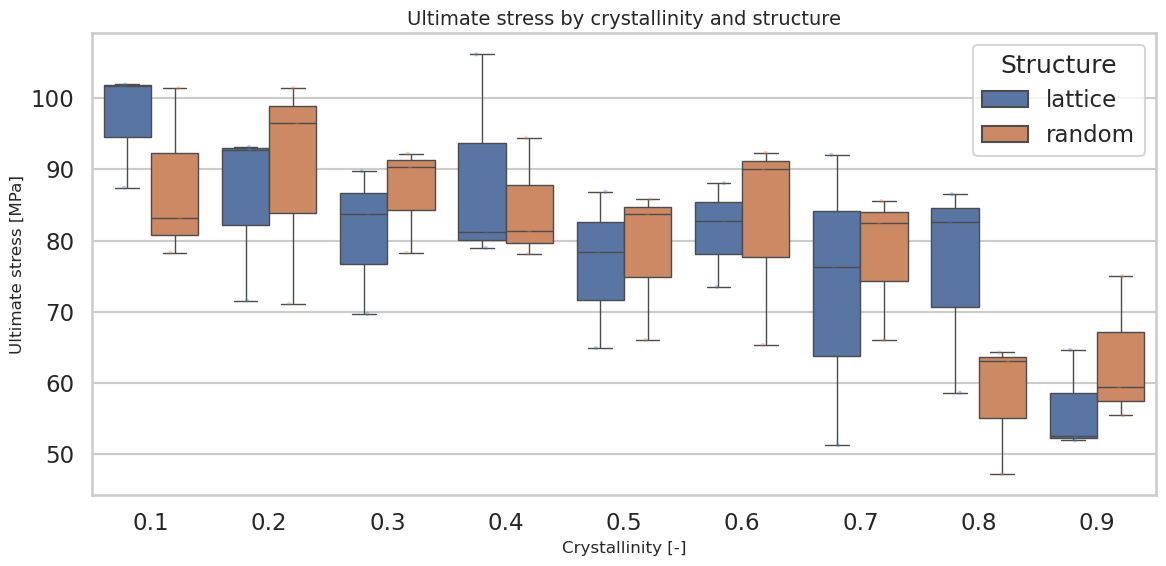

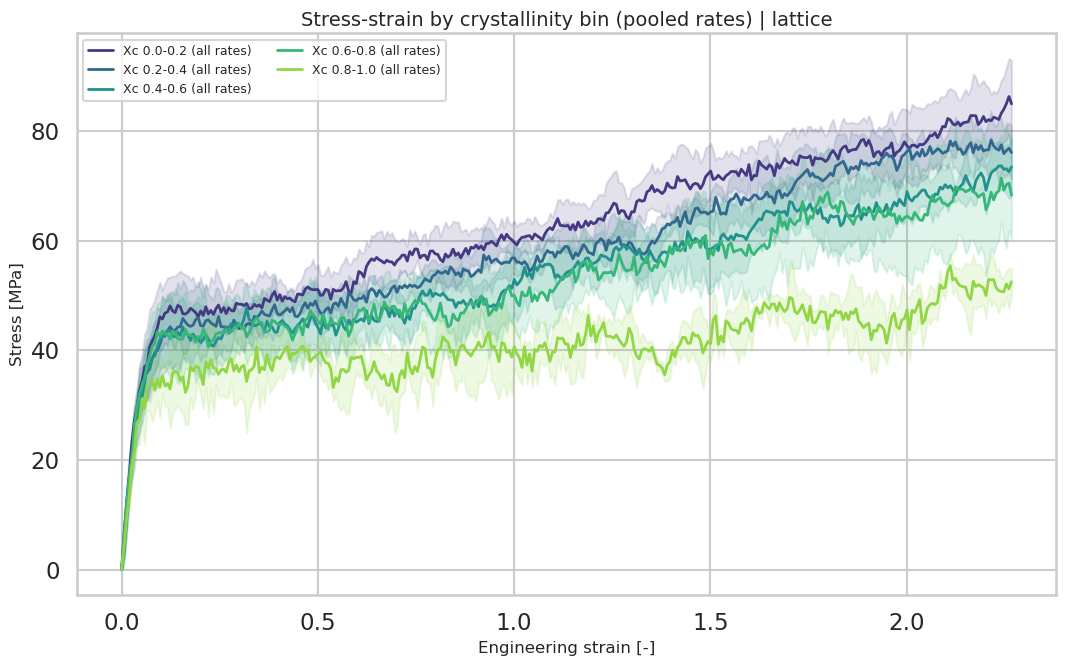

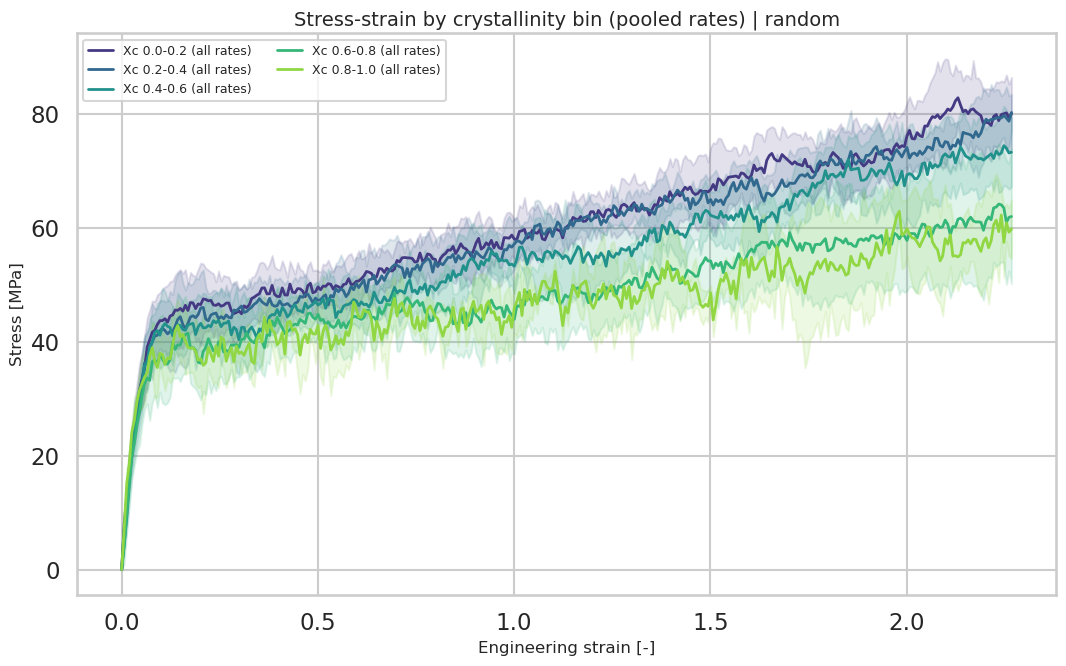

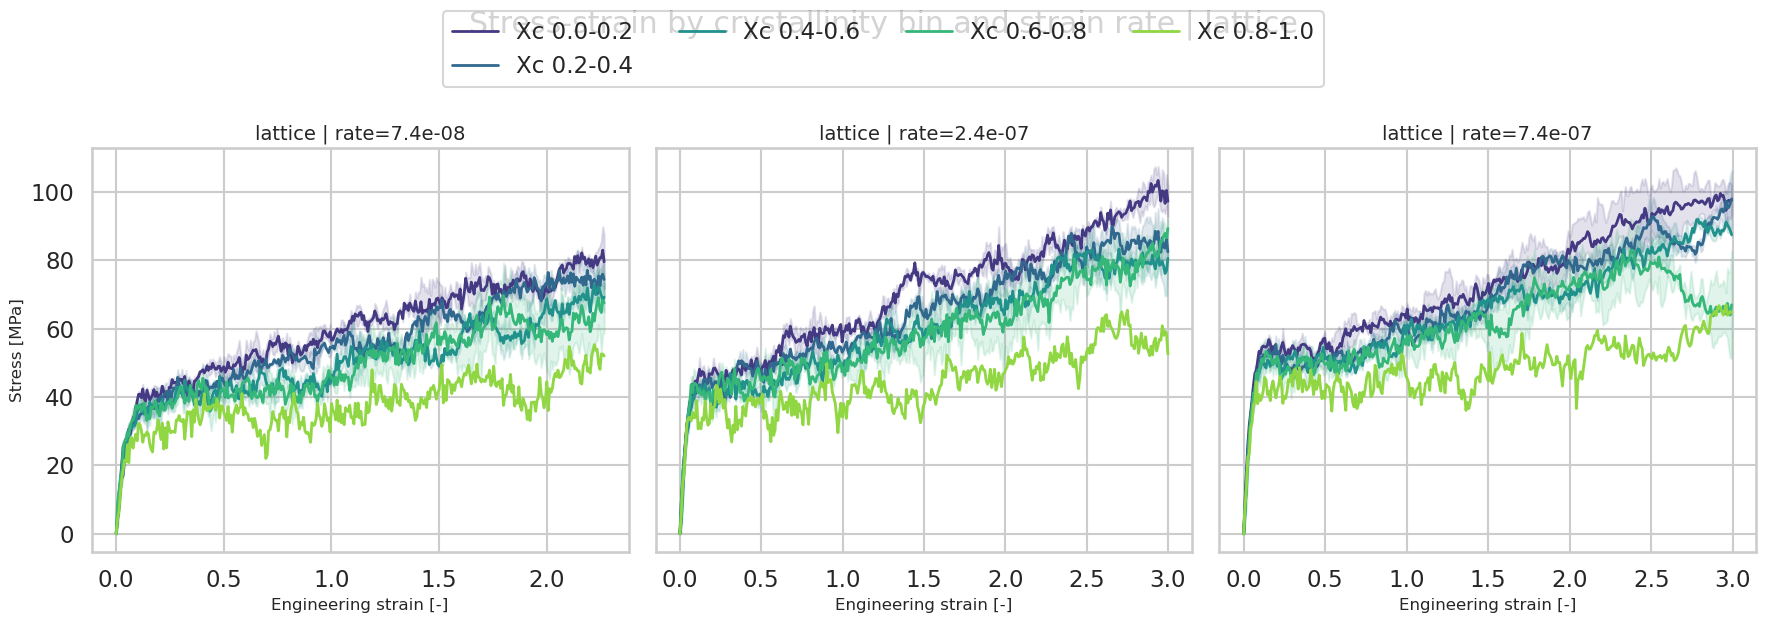

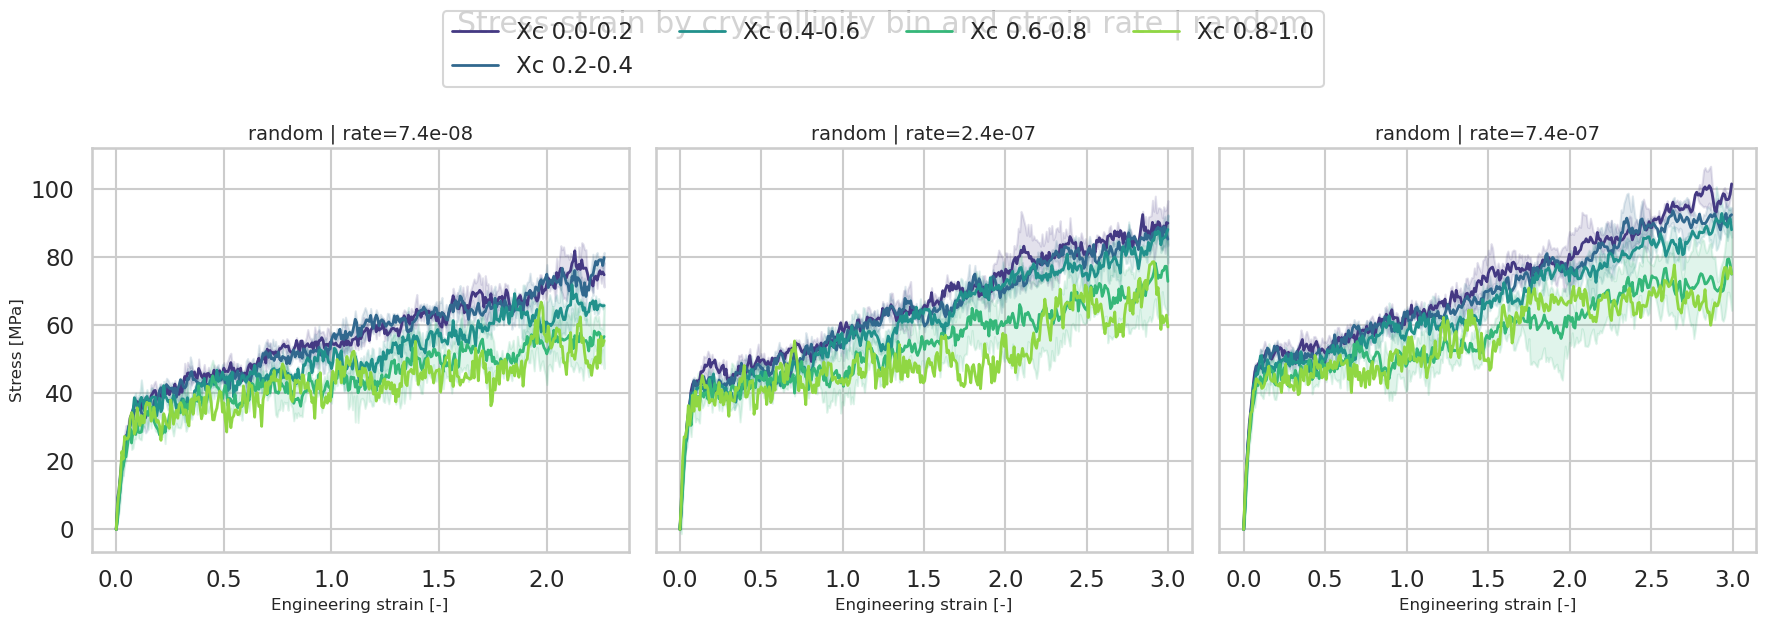

In [ ]:
def aggregate_curves(curve_df, n_grid=350):
    if len(curve_df) == 0:
        return None, None, None

    valid_max = []
    for a in curve_df["strain_arr"]:
        if isinstance(a, np.ndarray) and len(a) > 10:
            valid_max.append(np.max(a))

    if len(valid_max) == 0:
        return None, None, None

    max_common = min(valid_max)
    if not np.isfinite(max_common) or max_common <= 0:
        return None, None, None

    grid = np.linspace(0, max_common, n_grid)
    stack = []

    for _, row in curve_df.iterrows():
        s = row["strain_arr"]
        t = row["stress_arr"]
        if len(s) < 10 or len(s) != len(t):
            continue

        order = np.argsort(s)
        s = s[order]
        t = t[order]

        if np.unique(s).size < 10:
            continue

        stack.append(np.interp(grid, s, t))

    if len(stack) == 0:
        return None, None, None

    M = np.vstack(stack)
    return grid, M.mean(axis=0), M.std(axis=0)


# Exact-crystallinity mean±std curves in a 2x3 subplot:
# rows = structure (top=lattice, bottom=random), cols = strain-rate
structures = ["lattice", "random"]
rates = sorted(df_metrics["rate"].dropna().unique())
cr_values = sorted(df_metrics["crystallinity"].dropna().unique())

palette = sns.color_palette("viridis", n_colors=len(cr_values))
color_map = {cr: palette[i] for i, cr in enumerate(cr_values)}

fig, axes = plt.subplots(2, 3, figsize=(19, 10), sharex=True, sharey=True)

for r, structure in enumerate(structures):
    sub_structure = df_metrics[df_metrics["structure"] == structure]

    for c, rate in enumerate(rates):
        ax = axes[r, c]
        sub = sub_structure[np.isclose(sub_structure["rate"], rate)]

        for cr in cr_values:
            gdf = sub[np.isclose(sub["crystallinity"], cr)]
            x, y, ystd = aggregate_curves(gdf)
            if x is None:
                continue

            ax.plot(x, y, color=color_map[cr], lw=2, label=f"Xc={cr:.1f}")
            ax.fill_between(x, y - ystd, y + ystd, color=color_map[cr], alpha=0.12)

        ax.set_title(f"{structure} | rate={rate:.1e}")
        if r == 1:
            ax.set_xlabel("Engineering strain [-]")
        if c == 0:
            ax.set_ylabel("Stress [MPa]")
        ax.grid(True, alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=min(9, len(labels)), title="Crystallinity")

fig.suptitle("Stress-strain curves by exact crystallinity and strain rate", y=1.02)
plt.tight_layout()
plt.show()

## 8. Plot Stress-Strain Curves by Strain Rate

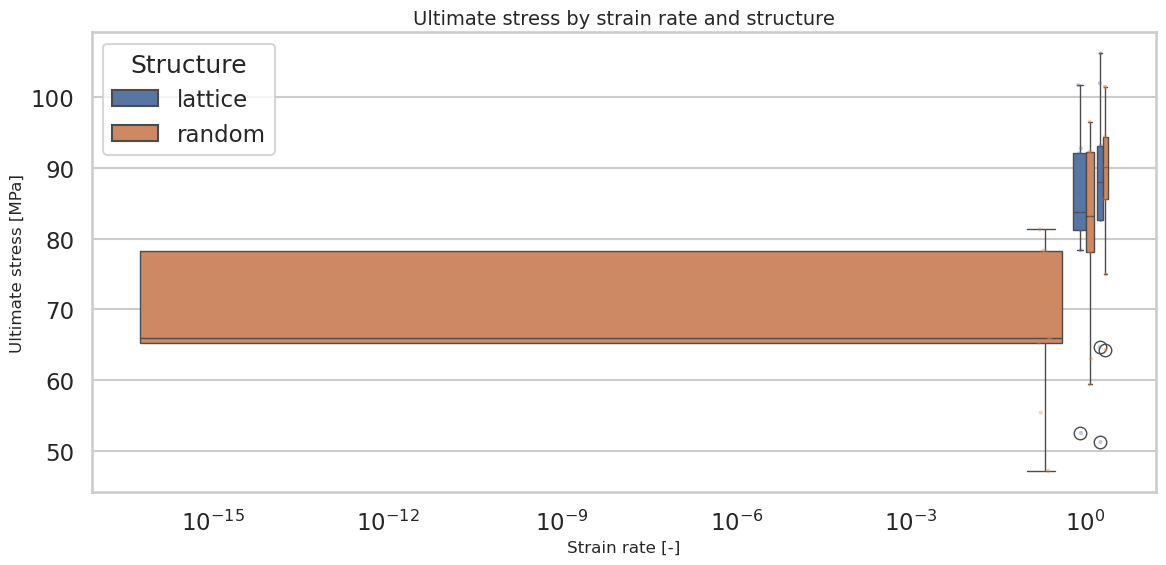

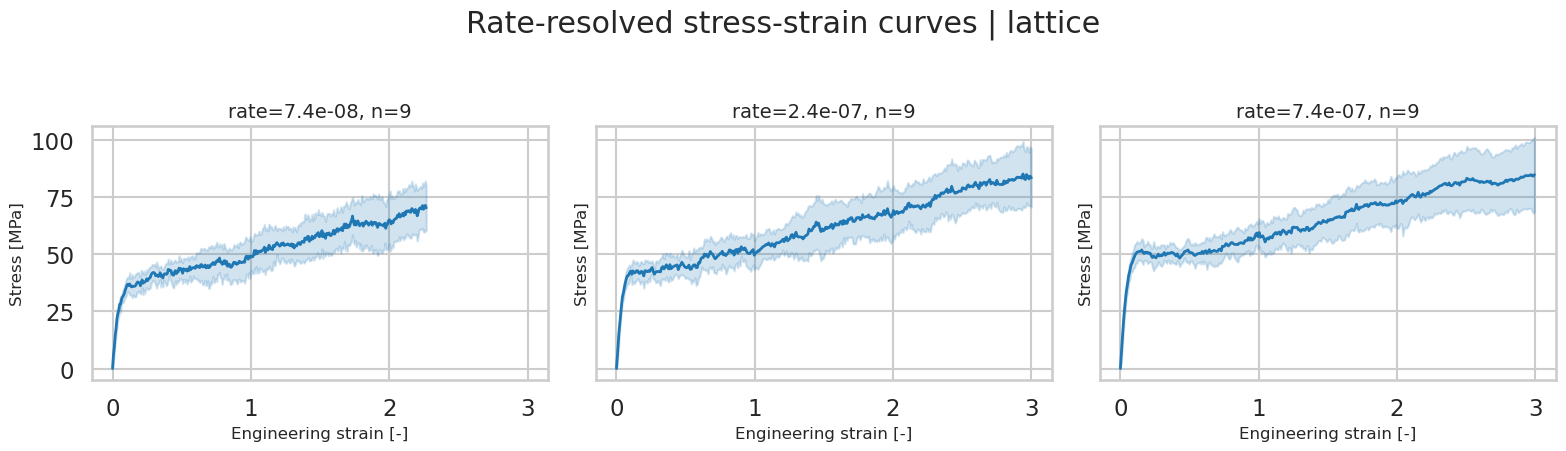

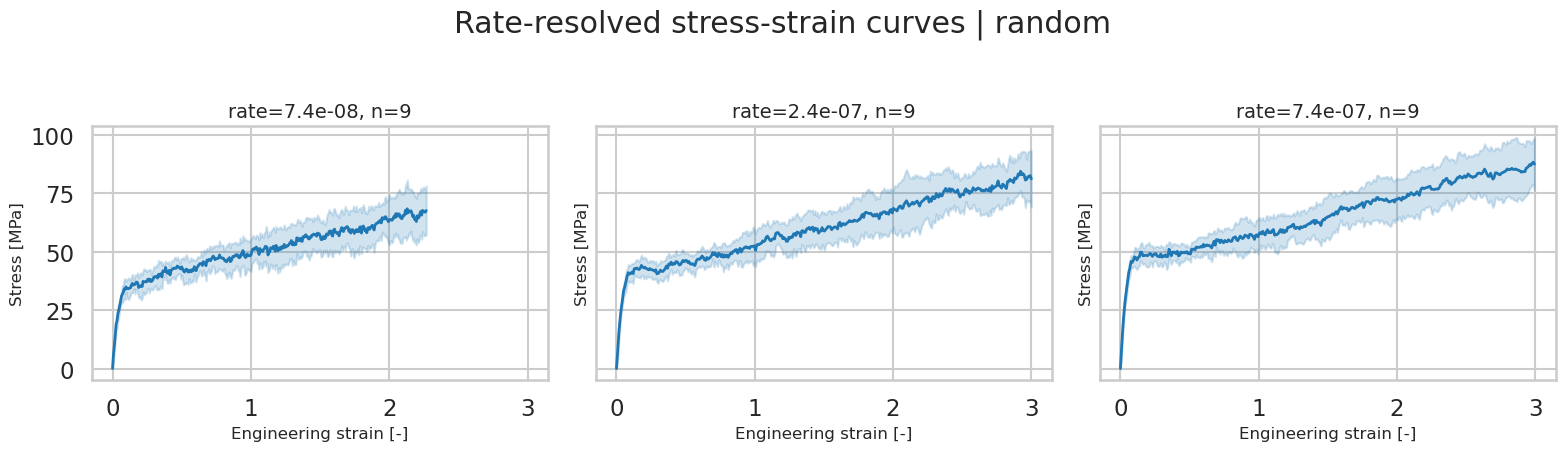

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = df_metrics.copy()
plot_df["rate_str"] = plot_df["rate"].map(lambda v: f"{v:.1e}")
sns.boxplot(data=plot_df, x="rate", y="ultimate_stress_mpa", hue="structure", ax=ax)
sns.stripplot(data=plot_df, x="rate", y="ultimate_stress_mpa", hue="structure", dodge=True, alpha=0.35, size=3, ax=ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="Structure", loc="best")
ax.set_xscale("log")
ax.set_title("Ultimate stress by strain rate and structure")
ax.set_xlabel("Strain rate [-]")
ax.set_ylabel("Ultimate stress [MPa]")
plt.tight_layout()
plt.show()

for structure in ["lattice", "random"]:
    sub = df_metrics[df_metrics["structure"] == structure]
    rates = sorted(sub["rate"].dropna().unique())

    n_cols = 3
    n_rows = int(np.ceil(len(rates) / n_cols)) if len(rates) else 1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)

    for i, rate in enumerate(rates):
        ax = axes[i]
        gdf = sub[np.isclose(sub["rate"], rate)]
        x, y, ystd = aggregate_curves(gdf)
        if x is None:
            ax.set_visible(False)
            continue

        ax.plot(x, y, color="tab:blue", lw=2)
        ax.fill_between(x, y - ystd, y + ystd, color="tab:blue", alpha=0.2)
        ax.set_title(f"rate={rate:.1e}, n={len(gdf)}")
        ax.set_xlabel("Engineering strain [-]")
        ax.set_ylabel("Stress [MPa]")

    for j in range(len(rates), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Rate-resolved stress-strain curves | {structure}", y=1.02)
    plt.tight_layout()
    plt.show()

## 9. Build Comparative Heatmaps and Response Surfaces

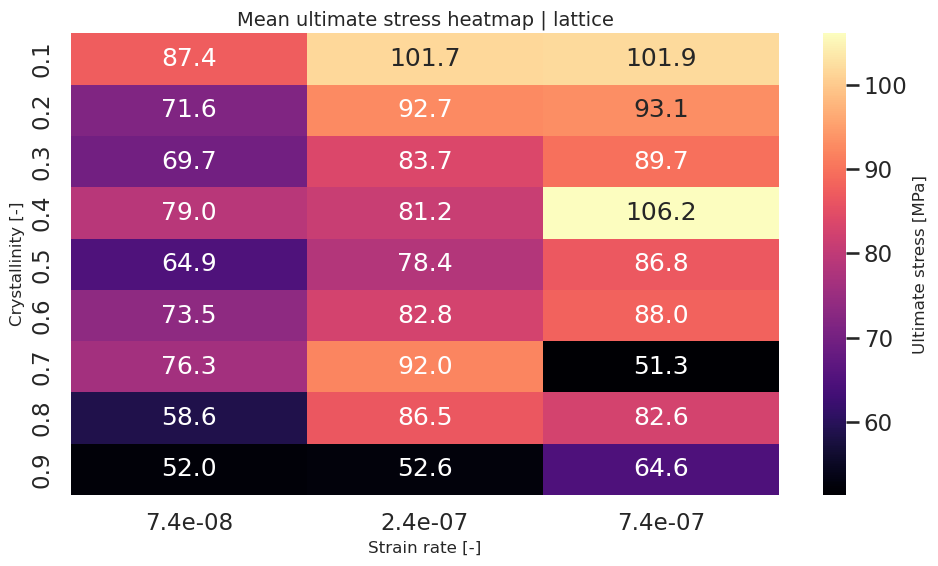

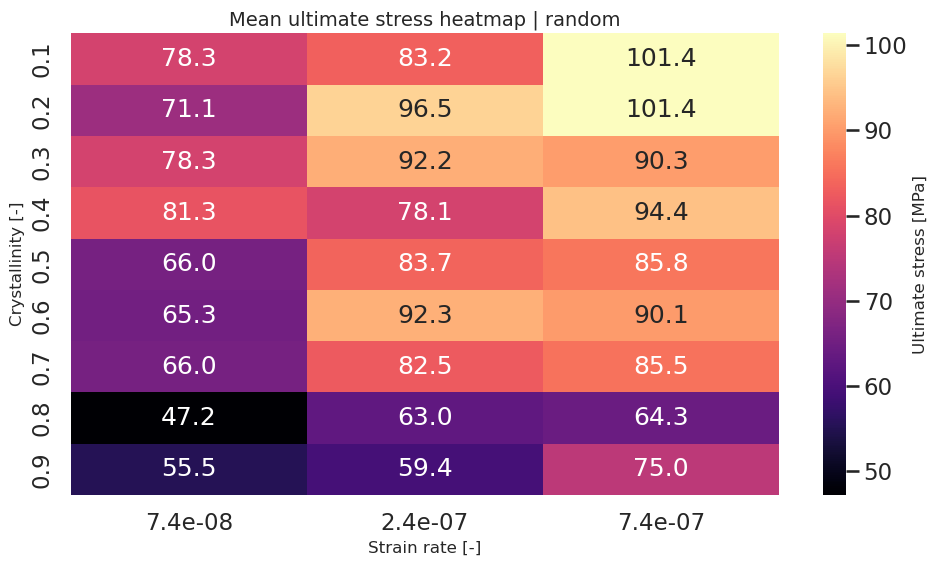

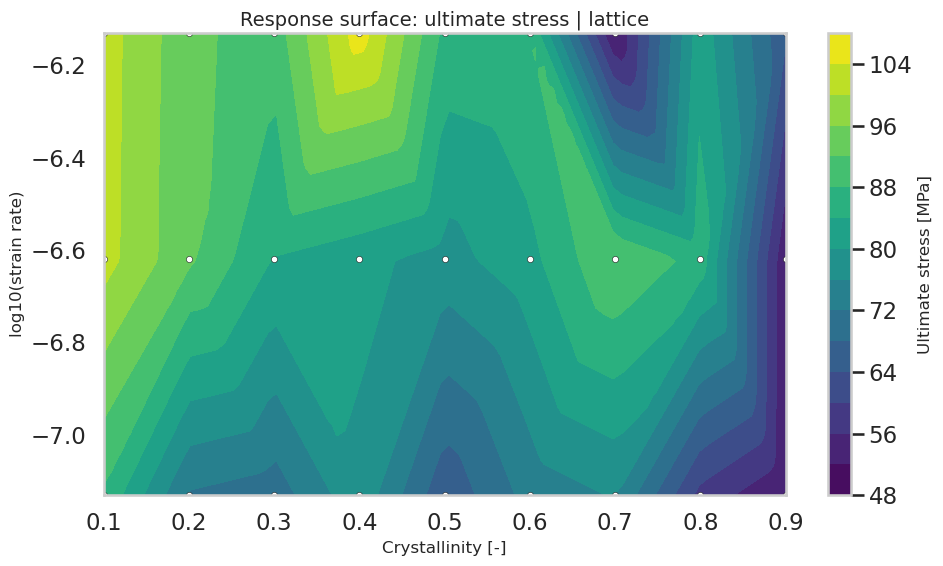

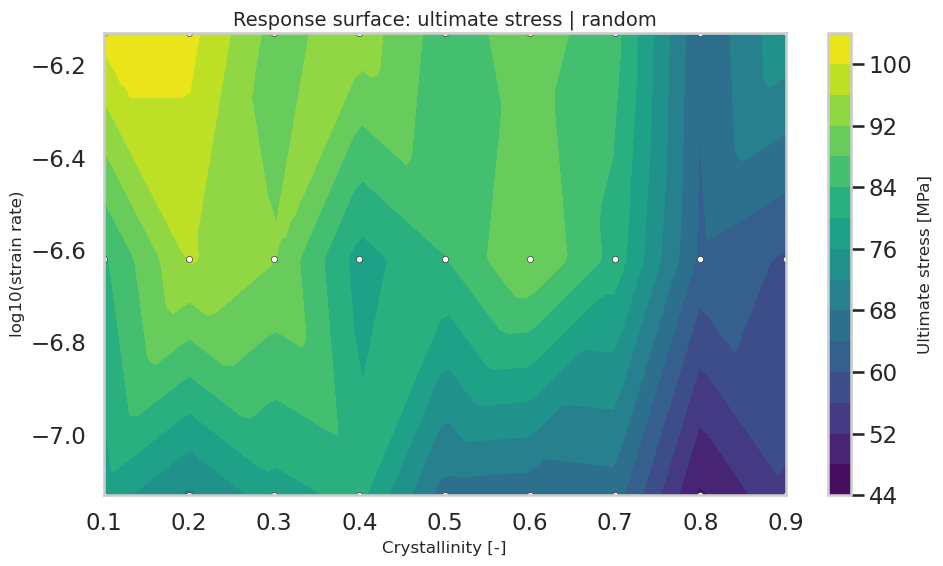

In [18]:
for structure in ["lattice", "random"]:
    sub = df_metrics[df_metrics["structure"] == structure].copy()

    pivot = (
        sub.groupby(["crystallinity", "rate"], as_index=False)["ultimate_stress_mpa"]
        .mean()
        .pivot(index="crystallinity", columns="rate", values="ultimate_stress_mpa")
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(pivot, cmap="magma", annot=True, fmt=".1f", cbar_kws={"label": "Ultimate stress [MPa]"}, ax=ax)
    ax.set_title(f"Mean ultimate stress heatmap | {structure}")
    ax.set_xlabel("Strain rate [-]")
    ax.set_ylabel("Crystallinity [-]")
    plt.tight_layout()
    plt.show()

# Response surface over crystallinity and log10(rate)
resp = (
    df_metrics.groupby(["structure", "crystallinity", "log10_rate"], as_index=False)["ultimate_stress_mpa"]
    .mean()
)

for structure in ["lattice", "random"]:
    sub = resp[resp["structure"] == structure]
    if len(sub) < 6:
        continue

    xi = np.linspace(sub["crystallinity"].min(), sub["crystallinity"].max(), 80)
    yi = np.linspace(sub["log10_rate"].min(), sub["log10_rate"].max(), 80)
    XX, YY = np.meshgrid(xi, yi)

    ZZ = griddata(
        points=sub[["crystallinity", "log10_rate"]].to_numpy(),
        values=sub["ultimate_stress_mpa"].to_numpy(),
        xi=(XX, YY),
        method="linear",
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    cs = ax.contourf(XX, YY, ZZ, levels=15, cmap="viridis")
    cbar = plt.colorbar(cs, ax=ax)
    cbar.set_label("Ultimate stress [MPa]")
    ax.scatter(sub["crystallinity"], sub["log10_rate"], c="white", s=20, edgecolor="k", linewidth=0.4)
    ax.set_title(f"Response surface: ultimate stress | {structure}")
    ax.set_xlabel("Crystallinity [-]")
    ax.set_ylabel("log10(strain rate)")
    plt.tight_layout()
    plt.show()

## 10. Fit Predictive Models for Property Sensitivity

In [19]:
model_df = df_metrics[[
    "structure", "crystallinity", "rate", "log10_rate",
    "elastic_modulus_mpa", "yield_stress_mpa", "failure_strain", "auc_mpa",
    "ultimate_stress_mpa"
]].copy()

feature_cols = ["structure", "crystallinity", "log10_rate", "elastic_modulus_mpa", "yield_stress_mpa", "failure_strain", "auc_mpa"]
X = model_df[feature_cols]
y = model_df["ultimate_stress_mpa"]

numeric_features = [c for c in feature_cols if c != "structure"]
categorical_features = ["structure"]

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=SEED),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=SEED),
}

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
rows = []

for name, estimator in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", estimator)])
    r2_scores = cross_val_score(pipe, X, y, cv=cv, scoring="r2")
    mae_scores = -cross_val_score(pipe, X, y, cv=cv, scoring="neg_mean_absolute_error")
    rows.append({
        "model": name,
        "r2_mean": np.mean(r2_scores),
        "r2_std": np.std(r2_scores),
        "mae_mean": np.mean(mae_scores),
        "mae_std": np.std(mae_scores),
    })

cv_results = pd.DataFrame(rows).sort_values("r2_mean", ascending=False)
cv_results

,model,r2_mean,r2_std,mae_mean,mae_std
1,Ridge,0.667639,0.287514,5.611896,1.578156
0,LinearRegression,0.654071,0.326415,5.296666,1.339272
2,RandomForest,0.568610,0.383282,6.398745,2.104159


## 11. Export Figures, Tables, and Reproducible Outputs

In [20]:
# Export core tabular outputs
clean_path = OUT_DIR / "clean_curve_table.csv"
metrics_path = OUT_DIR / "curve_metrics.csv"
group_path = OUT_DIR / "group_statistics.csv"
cv_path = OUT_DIR / "model_cv_results.csv"
summary_path = OUT_DIR / "analysis_summary.json"

df.to_csv(clean_path, index=False)
df_metrics.to_csv(metrics_path, index=False)
group_stats.to_csv(group_path, index=False)
cv_results.to_csv(cv_path, index=False)

summary_payload = {
    "n_curves": int(len(df_metrics)),
    "structures": sorted(df_metrics["structure"].dropna().unique().tolist()),
    "crystallinity_values": sorted(df_metrics["crystallinity"].dropna().unique().tolist()),
    "rate_values": sorted(df_metrics["rate"].dropna().unique().tolist()),
    "best_model": cv_results.iloc[0].to_dict() if len(cv_results) else None,
}

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2)

print("Exported files:")
for p in [clean_path, metrics_path, group_path, cv_path, summary_path]:
    print(" -", p)

Exported files:
 - /home/jmatxain/ipproject/outputs/stress_strain_analysis/clean_curve_table.csv
 - /home/jmatxain/ipproject/outputs/stress_strain_analysis/curve_metrics.csv
 - /home/jmatxain/ipproject/outputs/stress_strain_analysis/group_statistics.csv
 - /home/jmatxain/ipproject/outputs/stress_strain_analysis/model_cv_results.csv
 - /home/jmatxain/ipproject/outputs/stress_strain_analysis/analysis_summary.json


## Interpretation and Next Steps

Use this section after execution to summarize:
- Which structure shows higher ultimate stress at fixed crystallinity and strain rate.
- Whether rate sensitivity is monotonic in log10(rate).
- How crystallinity shifts elastic modulus, yield stress, and toughness (AUC).
- Which model best predicts ultimate stress and what that implies for nonlinear interactions.

Recommended next steps:
1. Add bootstrapped confidence bands for all grouped curves.
2. Introduce sample-weighted modeling if replication counts are unbalanced.
3. Extend targets to multi-output prediction (yield stress, failure strain, modulus) with uncertainty estimation.
4. Integrate this notebook with automated batch runs for new simulation folders.